## HateXplain - 3 OBJECTIVES

### Multi Task Learning

* **Dataset:** HateXplain
* **Task :** Classification
* **Target 1:** Hate speech
* **Target 2:** Hate speech against woman
* **Target 3:** Hate speech against homosexual

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import random
import torch
import numpy as np

from datasets import load_dataset

/home/lineccsa/mestrado/moo_research/mlmoo_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes
from machinemoo.analysis.metrics import compute_hypervolume_progress

import preprocessing as pp
from scalarization import NLPScalarization

In [4]:
# Setting a seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

## Dataset and Model

In [5]:
# Carregar o dataset HateXplain
dataset = load_dataset("Hate-speech-CNERG/hatexplain", trust_remote_code=True)


In [6]:
# model_name = "tum-nlp/bert-hateXplain"
#"hate-bert, uncased bert"
model_name="bert-base-uncased"

In [7]:
# model_name = "tum-nlp/bert-hateXplain"
#"hate-bert, uncased bert"
model_name="bert-base-uncased"

In [8]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


In [9]:
task_config = {
    "hate_speech": {"type": "hate_speech"},
    "women": {"type": "group_hate", "group": "Women"},
    "homosexual": {"type": "group_hate", "group": "Homosexual"}
}

train_dataloader = pp.get_dataloader(dataset['train'], task_config)

100%|██████████| 481/481 [00:48<00:00,  9.99it/s]


## MOO Modeling and Training

* MOO methods:
    * MOLA
    * Random Weights

In [10]:
opt_params = {
    'node_time_limit': 2,
    'target_size': 300,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
results = {}
task_names = list(task_config.keys())

### MOLA

11:19:28 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 300, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
11:19:28 | DEBUG | machinemoo | Finding 1th individual minimum
Epoch 1/3: 100%|██████████| 241/241 [00:02<00:00, 100.29it/s]


Epoch 1 - Average loss: 0.2449


Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 110.60it/s]


Epoch 2 - Average loss: 0.2397


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 109.48it/s]


...

Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 105.58it/s]


Epoch 2 - Average loss: 0.2042


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 108.83it/s]


Epoch 3 - Average loss: 0.2043
new solution dominated [0.58913884 0.35181403 0.26639405]


12:03:15 | DEBUG | machinemoo | Calculated weights: [1. 0. 0.]
12:03:15 | DEBUG | machinemoo | Importance: 1.887379141862766e-15
12:03:15 | DEBUG | machinemoo | Global lower bound (y*): [0.58868677 0.35024186 0.2652421 ]
12:03:15 | DEBUG | machinemoo | Iteration 301
12:03:15 | DEBUG | machinemoo | Solutions list: [array([0.58944186, 0.35097354, 0.2681907 ]), array([0.58896705, 0.35142435, 0.266605  ]), array([0.5897094 , 0.35024186, 0.26760036]), array([0.58868677, 0.3521342 , 0.26635458]), array([0.58937014, 0.3521108 , 0.26555131]), array([0.58885668, 0.3516576 , 0.26584574]), array([0.5893957 , 0.35116143, 0.26572388]), array([0.5892105 , 0.35179496, 0.26582874]), array([0.58934518, 0.35201143, 0.26560344]), array([0.58946671, 0.35166778, 0.26560825]), array([0.58935819, 0.35184413, 0.26558951]), array([0.58924227, 0.35150598, 0.26580989]), array([0.58926903, 0.35148067, 0.26562493]), array([0.58903269, 0.35240907, 0.26569487]), array([0.58962214, 0.3517325 , 0.26535557]), array([0.

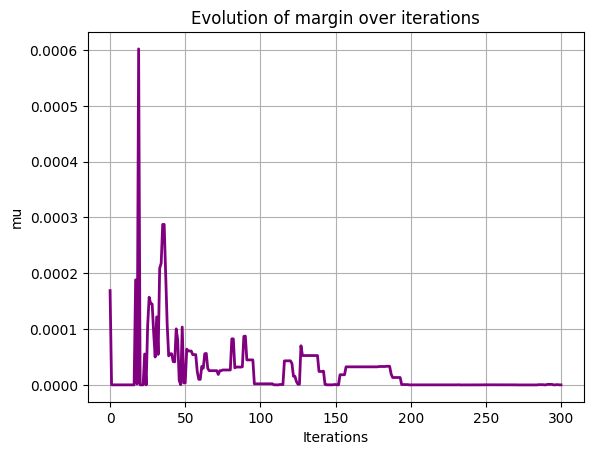

12:03:15 | INFO | machinemoo | Fit runtime: 2626.57 seconds


In [11]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

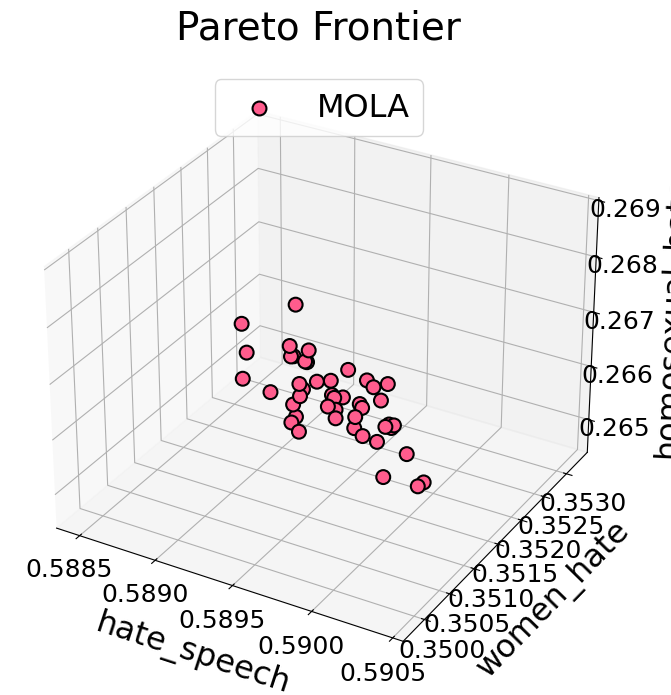

In [12]:
title="Conflict between losses in training to detect hate speech"
plot_pareto(methods={'mola': results['mola']['objectives']},
            labels=task_names, 
            # title=title,
            fontsize=23,
            figsize=(10,7),
            save_path='images/3_objs_mola.pdf'
            )

12:03:15 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 300, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
12:03:15 | DEBUG | machinemoo | Finding 1th individual minimum
Epoch 1/3: 100%|██████████| 241/241 [00:02<00:00, 99.30it/s] 


Epoch 1 - Average loss: 0.2360


Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 101.83it/s]


Epoch 2 - Average loss: 0.2318


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 102.86it/s]


...

Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 116.27it/s]


Epoch 2 - Average loss: 0.0920


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 116.13it/s]


Epoch 3 - Average loss: 0.0931
new solution added [0.5895534  0.35207766 0.26559679]


12:48:21 | DEBUG | machinemoo | Calculated weights: [0. 1. 0.]
12:48:21 | DEBUG | machinemoo | Importance: 9.996820038438159e-11
12:48:21 | DEBUG | machinemoo | Global lower bound (y*): [0.58886587 0.34991526 0.26526063]
12:48:21 | DEBUG | machinemoo | Iteration 301
12:48:21 | DEBUG | machinemoo | Solutions list: [array([0.5895534 , 0.35207766, 0.26559679]), array([0.58894703, 0.3521505 , 0.26640438]), array([0.58941432, 0.35092411, 0.2681516 ]), array([0.58962869, 0.34991526, 0.26781679]), array([0.58929988, 0.35213509, 0.26617714]), array([0.58953346, 0.35009936, 0.26815433]), array([0.58908064, 0.35258464, 0.26612802]), array([0.58915902, 0.3521722 , 0.26552885]), array([0.58936742, 0.352572  , 0.26526063]), array([0.58933155, 0.35123565, 0.26794814]), array([0.58908289, 0.35219033, 0.26616401]), array([0.58886587, 0.35224385, 0.26636683]), array([0.58908465, 0.35261932, 0.26569411]), array([0.58898778, 0.35299984, 0.26606213]), array([0.58892419, 0.35306142, 0.26609596]), array([0.

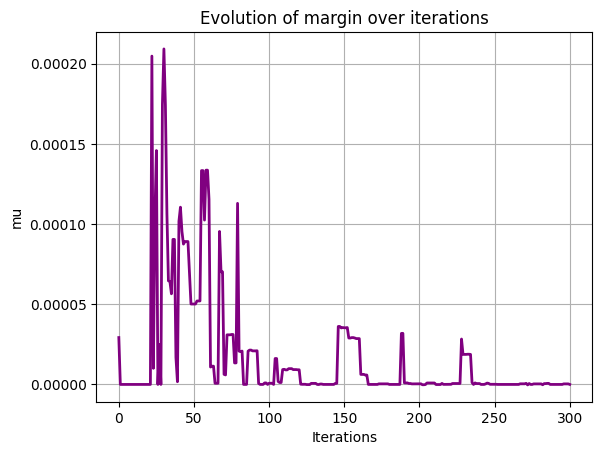

12:48:21 | INFO | machinemoo | Fit runtime: 2705.74 seconds


In [13]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names,
                            gradient = True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[f'{method}_grad'] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

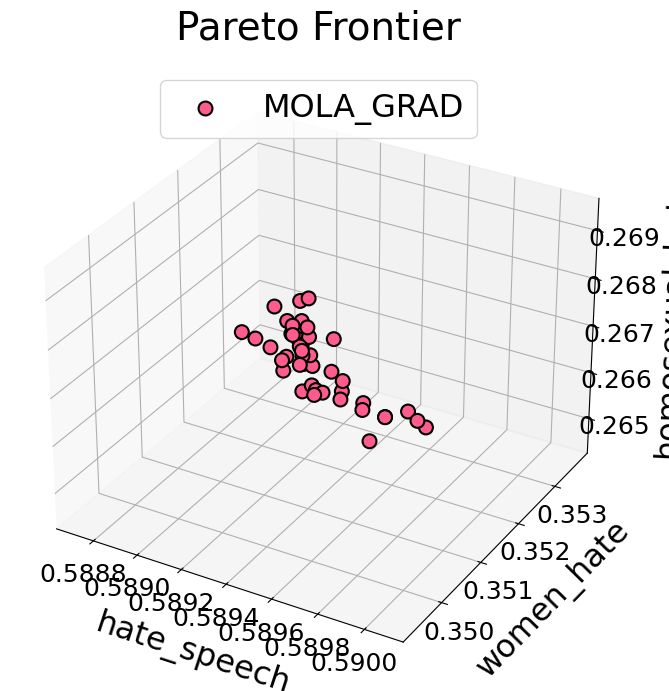

In [14]:
title="Conflict between losses in training to detect hate speech"
plot_pareto(methods={'mola_grad': objs},
            labels=task_names, 
            # title=title,
            fontsize=23,
            figsize=(10,7),
            save_path='images/3_objs_mola_grad.pdf'
            )

### Random Weights

In [15]:
method = 'random_weight'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[f'{method}_grad'] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

12:48:22 | WARNING | machinemoo | Ignored parameters for random_weights: {'targetGap', 'nodeGap', 'nodeTimeLimit'}
12:48:22 | DEBUG | machinemoo | Filtered parameters for random_weights: {'targetSize': 300, 'norm': False}
12:48:22 | DEBUG | machinemoo.moo.random_weights | Finding 1th individual minima
Epoch 1/3: 100%|██████████| 241/241 [00:02<00:00, 111.61it/s]


Epoch 1 - Average loss: 0.2277


Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 114.25it/s]


Epoch 2 - Average loss: 0.2239


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 112.51it/s]


...

Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 108.95it/s]


Epoch 2 - Average loss: 0.1170


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 109.39it/s]


Epoch 3 - Average loss: 0.1170


13:30:13 | DEBUG | machinemoo.moo.random_weights | 300th solution


## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

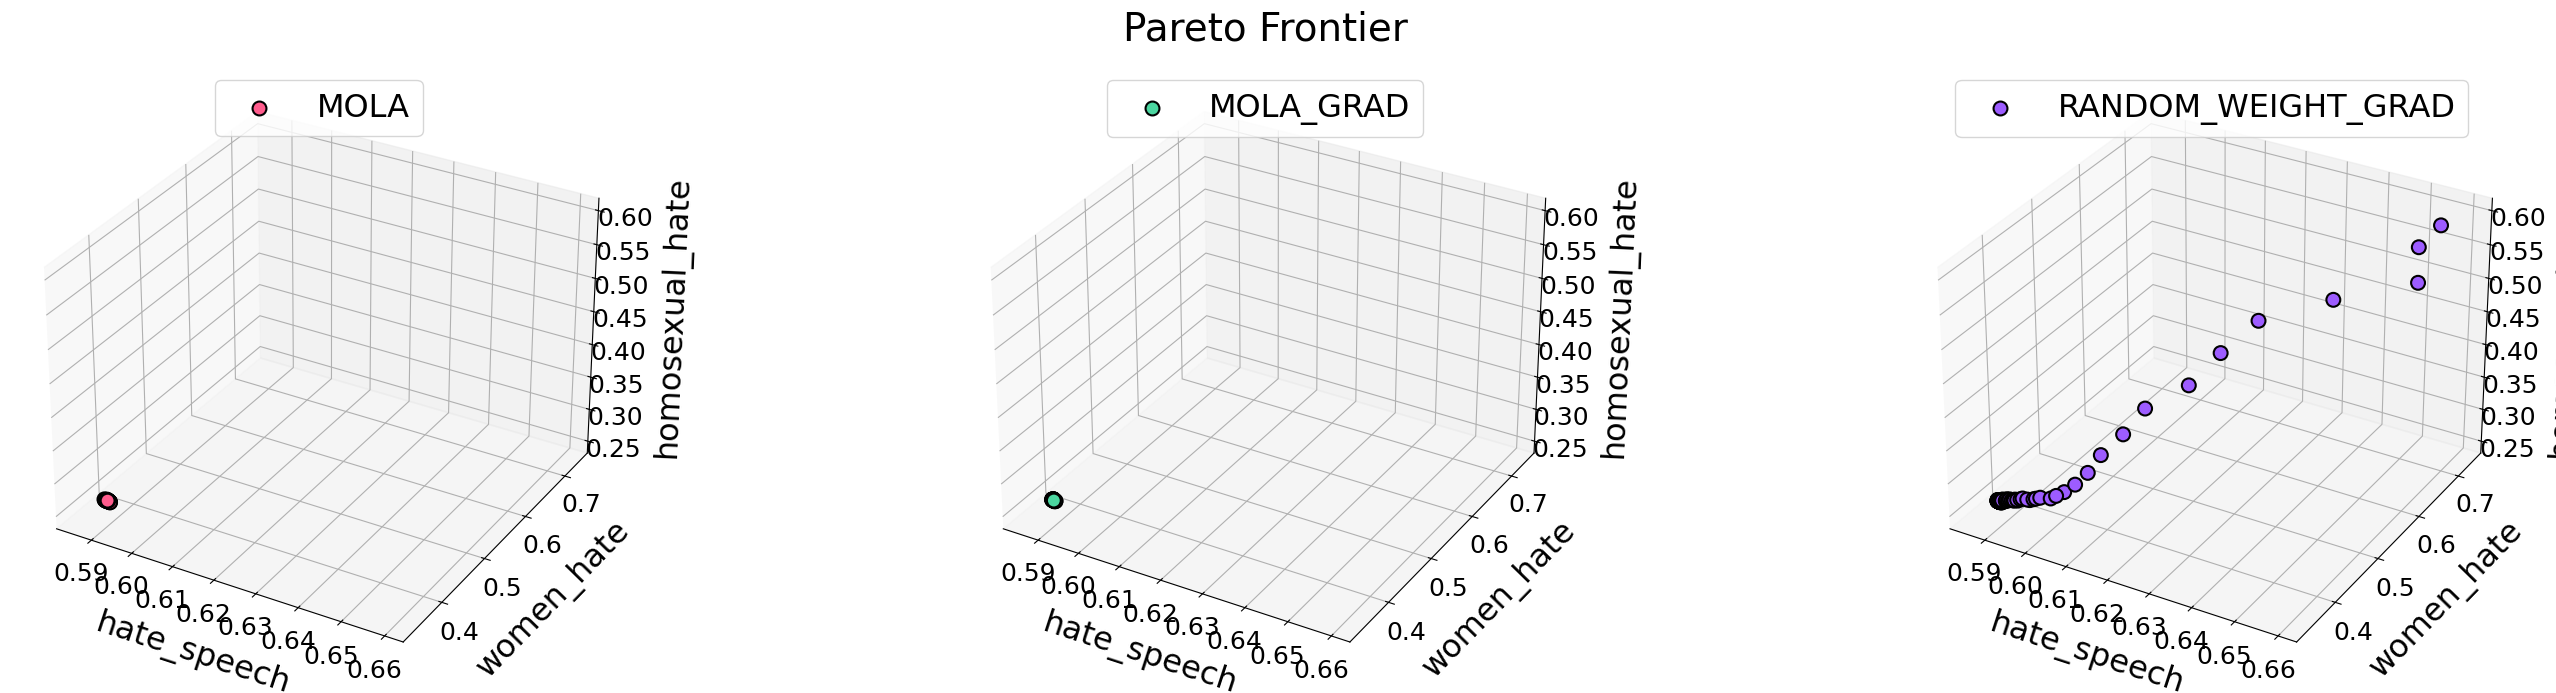

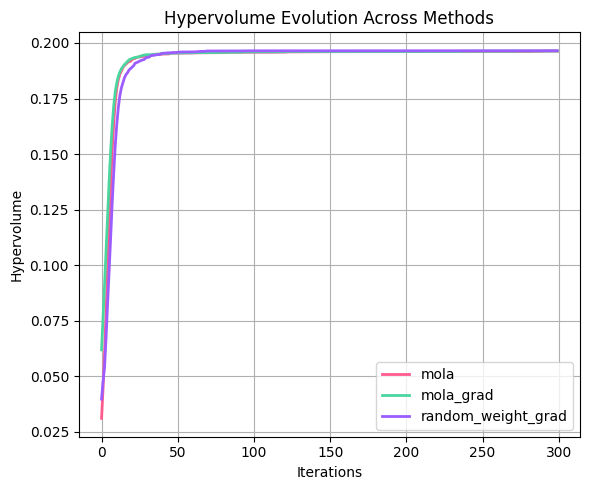

In [ ]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

colors_pareto = ['#FF5C8D', '#FF5C8D', '#FF5C8D']
colors_hv = ['#FF5C8D', '#4BD6A0', '#9D5CFF']
title = ""
plot_pareto(methods=pareto_dict,
            labels=task_names, 
            # title=title,
            fontsize=23,
            figsize=(10,7),
            save_path='images/3_objs_methods.pdf'
            )
plot_multiple_hypervolumes(methods_hv=hypervolumes_dict)